# Dataset Exploration & Feature Engineering Notebook
# This notebook performs initial analysis and visual inspection of NASA battery datasets used in the study.


In [ ]:
import pandas as pd
import os
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import shutil



# Loading data to the drive

## Downloading data from kaggle

In [ ]:
#path = kagglehub.dataset_download("patrickfleith/nasa-battery-dataset")
#print("Path to dataset files:", path)


## Mounting into the drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Loading the dataset into the drive

In [ ]:

# Set target path in Drive
#drive_path = '/content/drive/MyDrive/BCU/THESIS/datasets/'



## Verification in the dataset has been loaded

In [ ]:

drive_path = '/content/drive/MyDrive/BCU/THESIS/datasets/cleaned_dataset'

# List files in the dataset folder
files = os.listdir(drive_path)

# Print the list
for f in files:
    print(f)


metadata.csv
extra_infos
data


 Everything looks in place

# Exploring the datasets

## Metadata dataset

In [ ]:

meta_path = '/content/drive/MyDrive/BCU/THESIS/datasets/cleaned_dataset/metadata.csv'
metadata = pd.read_csv(meta_path)

# Preview
metadata.head()


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


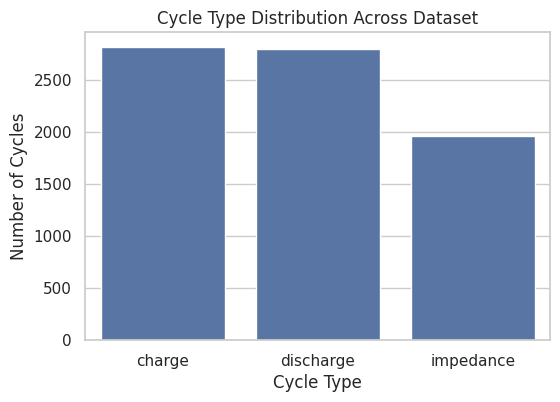

In [ ]:

# Count of charge, discharge, and impedance cycles
plt.figure(figsize=(6,4))
sns.countplot(data=metadata, x='type', order=['charge', 'discharge', 'impedance'])
plt.title('Cycle Type Distribution Across Dataset')
plt.xlabel('Cycle Type')
plt.ylabel('Number of Cycles')
plt.show()


Each row = one cycle (charge, discharge, or impedance)



| Column                              | Meaning                                               |
| ----------------------------------- | ----------------------------------------------------- |
| `type`                              | charge, discharge, or impedance                       |
| `filename`                          | the actual CSV file to load                           |
| `battery_id`                        | e.g. B0047, B0005, etc.                               |
| `Capacity`                          | final capacity measured (Ah)                          |
| `Re`, `Rct`                         | internal resistance (for impedance)                   |
| `start_time`, `ambient_temperature` | potentially useful for long-term degradation analysis |


In [ ]:
# copy dataset
metadata_copy = metadata.copy()

# Drop impedance rows
metadata = metadata[metadata['type'].isin(['charge', 'discharge'])]

metadata.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
5,charge,[2010. 7. 21. 22. 38. ...,4,B0047,5,6,00006.csv,NaN,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN


In [ ]:
# Preview all types of cycles
metadata['type'].value_counts()

,count
type,
charge,2815
discharge,2794


### EDA for metadata

 **Cycle Type Distribution**

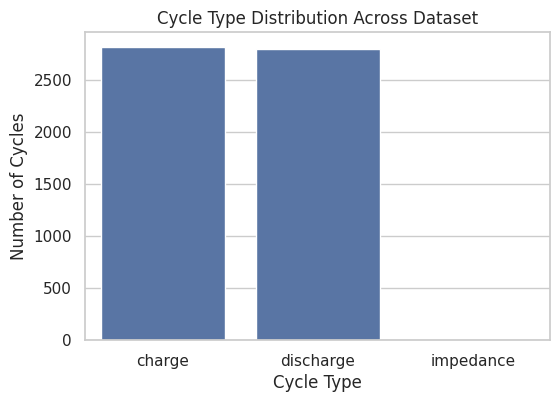

In [ ]:

# Count of charge, discharge, and impedance cycles
plt.figure(figsize=(6,4))
sns.countplot(data=metadata, x='type', order=['charge', 'discharge', 'impedance'])
plt.title('Cycle Type Distribution Across Dataset')
plt.xlabel('Cycle Type')
plt.ylabel('Number of Cycles')
plt.show()


## csv folders for each cycle and battery

In [ ]:
battery_cycle_files = (
    metadata
    .groupby('battery_id')
    .agg(
        total_cycles=('filename', 'count'),
        first_file=('filename', lambda x: sorted(x)[0]),
        last_file=('filename', lambda x: sorted(x)[-1])
    )
    .reset_index()
)
battery_cycle_files.sort_values(by='first_file')



,battery_id,total_cycles,first_file,last_file
24,B0047,184,00001.csv,00184.csv
22,B0045,184,00185.csv,00368.csv
25,B0048,184,00369.csv,00552.csv
23,B0046,184,00553.csv,00736.csv
20,B0043,275,00737.csv,01011.csv
11,B0032,97,01012.csv,01108.csv
16,B0039,122,01109.csv,01230.csv
17,B0040,122,01231.csv,01352.csv
8,B0029,97,01353.csv,01449.csv
7,B0028,80,01450.csv,01529.csv


In [ ]:

metadata_sorted = metadata.sort_values('filename').reset_index(drop=True)
metadata_sorted['dataset_index'] = metadata_sorted.index

fig = px.scatter(
    metadata_sorted,
    x='dataset_index',
    y='battery_id',
    color='battery_id',
    hover_data=['filename', 'type', 'test_id'],
    title='Battery Appearance Order in Dataset (Interactive)',
    labels={'dataset_index': 'Dataset Index', 'battery_id': 'Battery ID'},
    height=600
)

fig.update_traces(marker=dict(symbol='line-ns-open', size=10))
fig.update_layout(showlegend=True)
fig.show()


Batteries are in this order through out the dataset

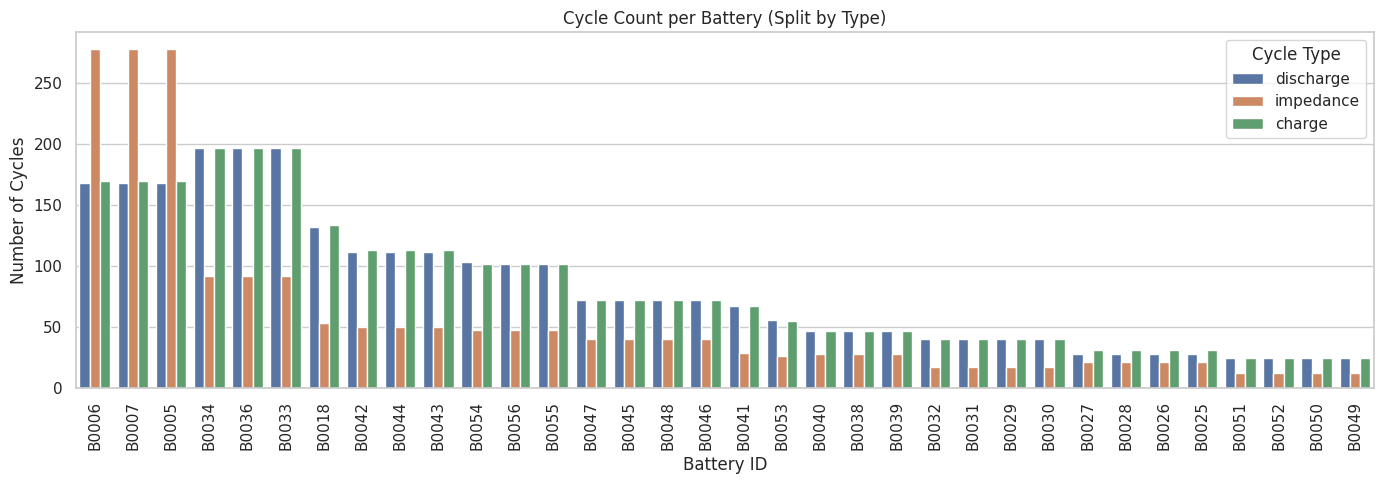

In [ ]:
plt.figure(figsize=(14,5))
sns.countplot(data=metadata, x='battery_id', hue='type', order=metadata['battery_id'].value_counts().index)
plt.title('Cycle Count per Battery (Split by Type)')
plt.xticks(rotation=90)
plt.xlabel('Battery ID')
plt.ylabel('Number of Cycles')
plt.legend(title='Cycle Type')
plt.tight_layout()
plt.show()


**Cycle Count per Battery**

### Temperature investegation

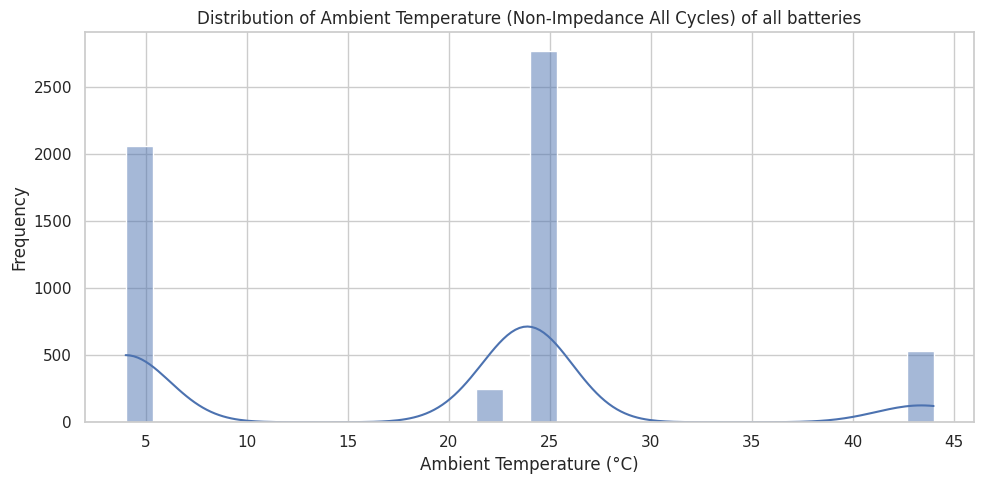

In [ ]:
metadata = pd.read_csv(metadata_path)
metadata_filtered = metadata[metadata['type'] != 'impedance']

plt.figure(figsize=(10, 5))
sns.histplot(metadata_filtered['ambient_temperature'], bins=30, kde=True)
plt.title("Distribution of Ambient Temperature (Non-Impedance All Cycles) of all batteries")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


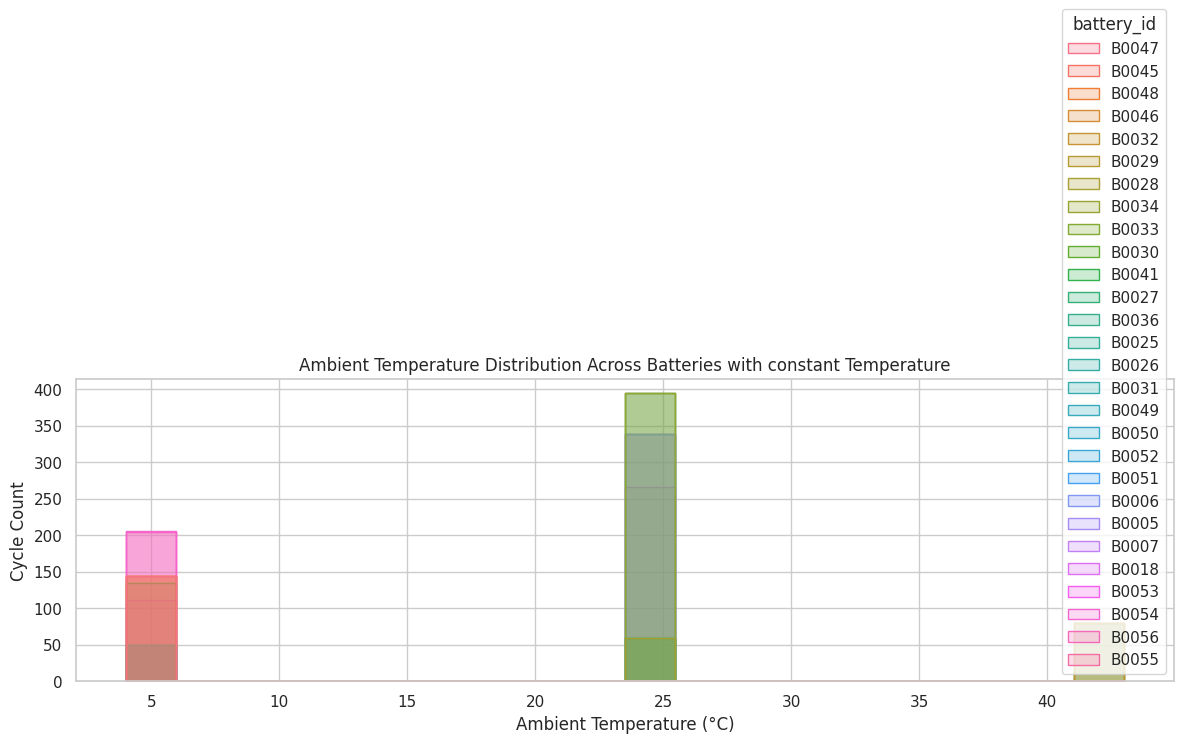

In [ ]:
batt_subset = metadata[
    (~metadata['battery_id'].isin(['B0038', 'B0039', 'B0040','B0042', 'B0043', 'B0044'])) &
    (metadata['type'] != 'impedance')
]

plt.figure(figsize=(12, 6))
sns.histplot(data=batt_subset, x='ambient_temperature', hue='battery_id', bins=20, kde=True, element='step')
plt.title("Ambient Temperature Distribution Across Batteries with constant Temperature")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("Cycle Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Droping impedance
metadata_filtered = metadata[metadata['type'] != 'impedance']

# Group by battery and count unique ambient temperatures
variation = metadata_filtered.groupby('battery_id')['ambient_temperature'].nunique().reset_index()
variation.columns = ['battery_id', 'unique_temp_count']

# Filter for batteries with more than 1 unique ambient temp
varying_batteries = variation[variation['unique_temp_count'] > 1]
varying_batteries


,battery_id,unique_temp_count
15,B0038,2
16,B0039,2
17,B0040,2
19,B0042,2
20,B0043,2
21,B0044,2


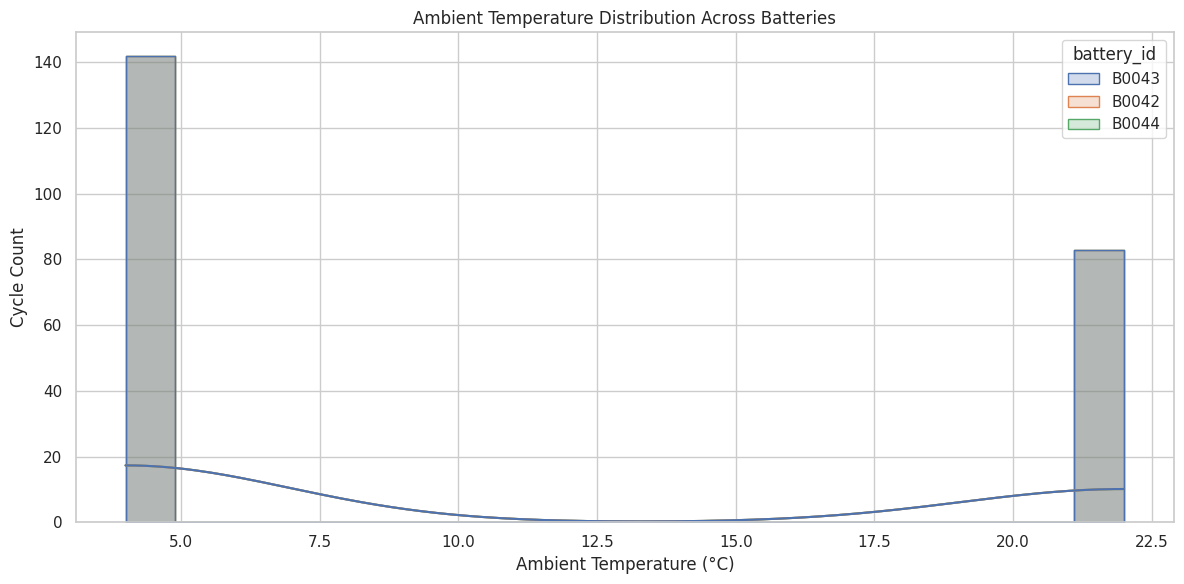

In [ ]:
batt_subset = metadata[
    (metadata['battery_id'].isin(['B0042', 'B0043', 'B0044'])) &
    (metadata['type'] != 'impedance')
]

plt.figure(figsize=(12, 6))
sns.histplot(data=batt_subset, x='ambient_temperature', hue='battery_id', bins=20, kde=True, element='step')
plt.title("Ambient Temperature Distribution Across Batteries")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("Cycle Count")
plt.grid(True)
plt.tight_layout()
plt.show()


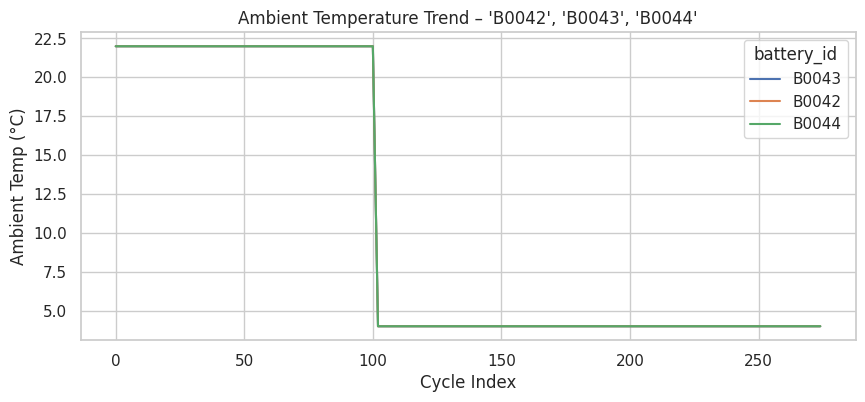

In [ ]:


batt = metadata[(metadata['battery_id'].isin(['B0042', 'B0043', 'B0044'])) & (metadata['type'] != 'impedance')]

plt.figure(figsize=(10, 4))
sns.lineplot(x='test_id', y='ambient_temperature', hue='battery_id', data=batt)
plt.title("Ambient Temperature Trend – 'B0042', 'B0043', 'B0044'")
plt.xlabel("Cycle Index")
plt.ylabel("Ambient Temp (°C)")
plt.grid(True)
plt.show()

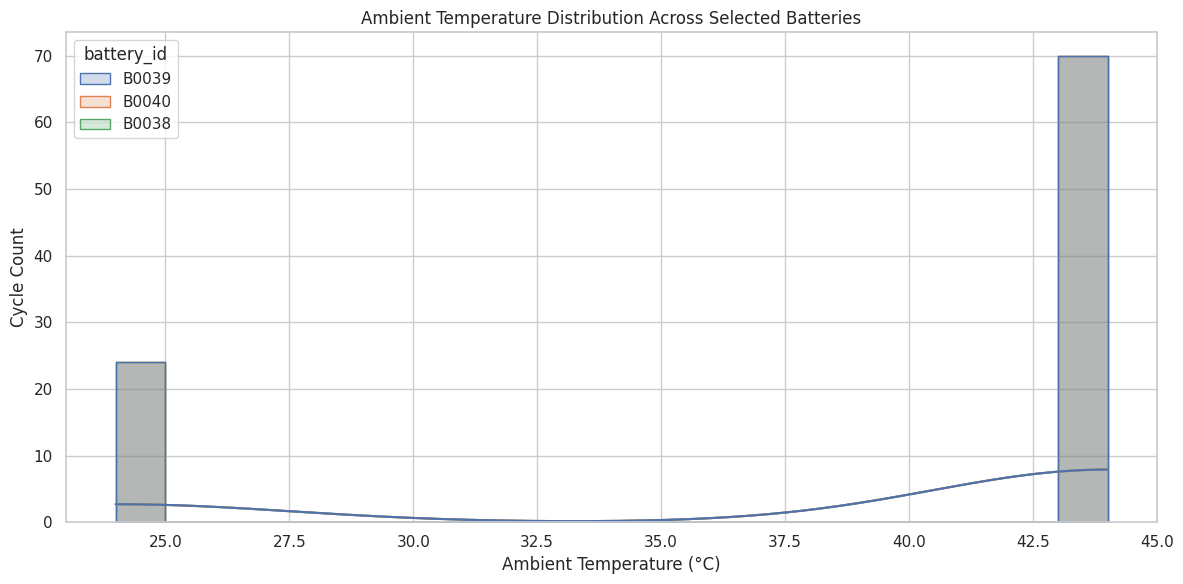

In [ ]:
batt_subset = metadata[
    (metadata['battery_id'].isin(['B0038', 'B0039', 'B0040'])) &
    (metadata['type'] != 'impedance')
]

plt.figure(figsize=(12, 6))
sns.histplot(data=batt_subset, x='ambient_temperature', hue='battery_id', bins=20, kde=True, element='step')
plt.title("Ambient Temperature Distribution Across Selected Batteries")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("Cycle Count")
plt.grid(True)
plt.tight_layout()
plt.show()


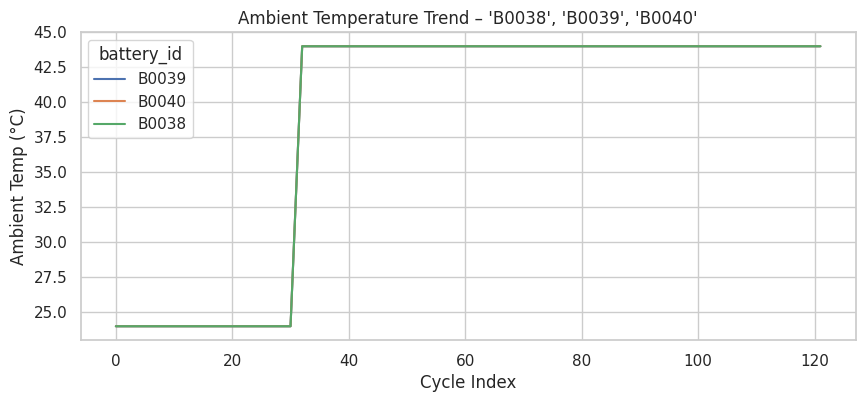

In [ ]:


batt = metadata[(metadata['battery_id'].isin(['B0038', 'B0039', 'B0040'])) & (metadata['type'] != 'impedance')]

plt.figure(figsize=(10, 4))
sns.lineplot(x='test_id', y='ambient_temperature', hue='battery_id', data=batt)
plt.title("Ambient Temperature Trend – 'B0038', 'B0039', 'B0040'")
plt.xlabel("Cycle Index")
plt.ylabel("Ambient Temp (°C)")
plt.grid(True)
plt.show()

So, it looks like we have three types of temperature behaviour, one group of batteries have a constant temperature through charge discharge cycles, one group heats up, and the last group cools down.

### Capacity investigation

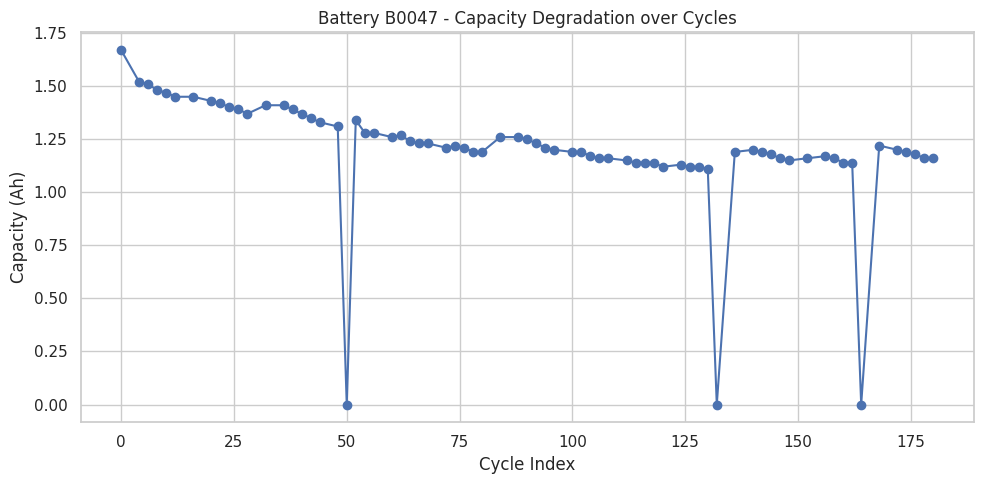

In [ ]:
b47_discharges = metadata[(metadata['battery_id'] == 'B0047') & (metadata['type'] == 'discharge')].copy()

b47_discharges['Capacity'] = pd.to_numeric(b47_discharges['Capacity'], errors='coerce').round(2)

b47_discharges = b47_discharges.dropna(subset=['Capacity'])

plt.figure(figsize=(10,5))
plt.plot(b47_discharges['test_id'], b47_discharges['Capacity'], marker='o', linestyle='-')
plt.title('Battery B0047 - Capacity Degradation over Cycles')
plt.xlabel('Cycle Index')
plt.ylabel('Capacity (Ah)')
plt.grid(True)
plt.tight_layout()
plt.show()


**Capacity Degradation Over Time (Single Battery)**

Now the batteries with constant T

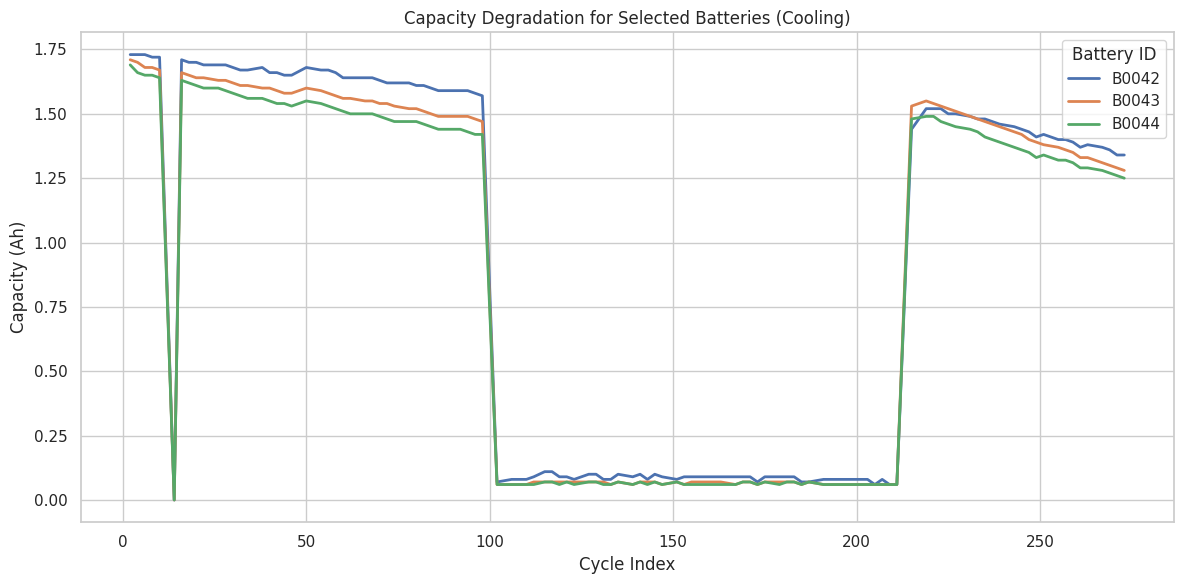

In [ ]:
# Making a safe copy of the metadata
metadata_clean = metadata.copy()

# Convert Capacity column to numeric and round
metadata_clean['Capacity'] = pd.to_numeric(metadata_clean['Capacity'], errors='coerce').round(2)

# Dropping invalid values (NaN)
metadata_clean = metadata_clean.dropna(subset=['Capacity'])
# Filtering only discharge cycles with valid capacity
cap_df = metadata_clean[(metadata_clean['type'] == 'discharge') & (metadata_clean['Capacity'].notna())]

# Sort
cap_df = cap_df.sort_values(by=['battery_id', 'test_id'])
selected_batteries = ['B0042', 'B0043', 'B0044']
cap_df_filtered = cap_df[cap_df['battery_id'].isin(selected_batteries)]

plt.figure(figsize=(12,6))
sns.lineplot(data=cap_df_filtered, x='test_id', y='Capacity', hue='battery_id', linewidth=2)
plt.title('Capacity Degradation for Selected Batteries (Cooling)')
plt.xlabel('Cycle Index')
plt.ylabel('Capacity (Ah)')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Battery ID')
plt.show()


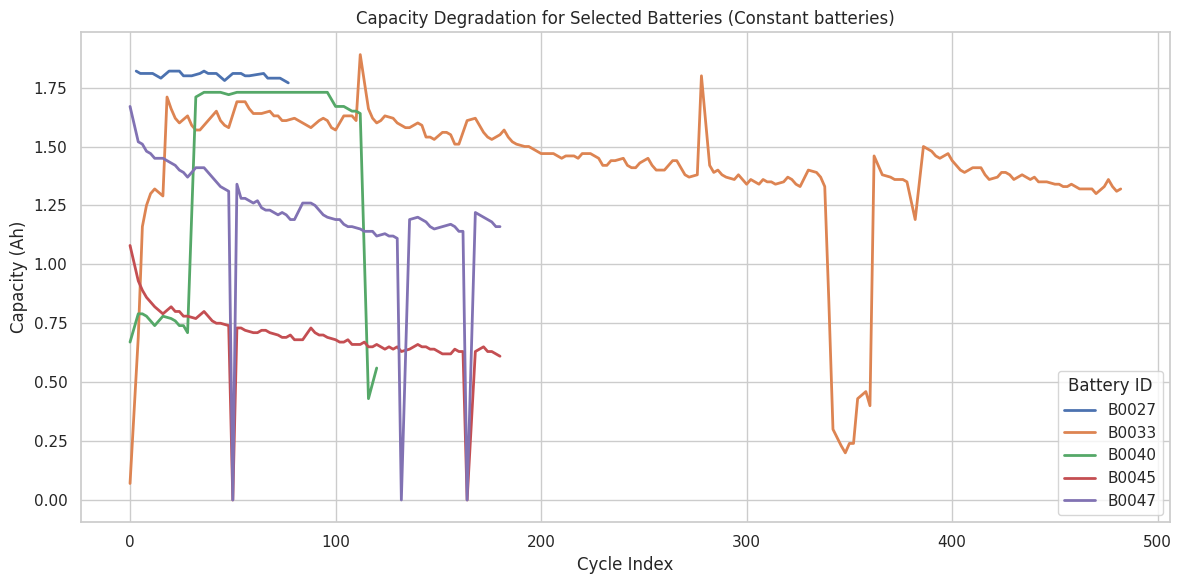

In [ ]:
metadata_clean = metadata.copy()

metadata_clean['Capacity'] = pd.to_numeric(metadata_clean['Capacity'], errors='coerce').round(2)

metadata_clean = metadata_clean.dropna(subset=['Capacity'])
cap_df = metadata_clean[(metadata_clean['type'] == 'discharge') & (metadata_clean['Capacity'].notna())]

cap_df = cap_df.sort_values(by=['battery_id', 'test_id'])
selected_batteries = ['B0047', 'B0045', 'B0033', 'B0040', 'B0027']
cap_df_filtered = cap_df[cap_df['battery_id'].isin(selected_batteries)]

plt.figure(figsize=(12,6))
sns.lineplot(data=cap_df_filtered, x='test_id', y='Capacity', hue='battery_id', linewidth=2)
plt.title('Capacity Degradation for Selected Batteries (Constant batteries)')
plt.xlabel('Cycle Index')
plt.ylabel('Capacity (Ah)')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Battery ID')
plt.show()


Now the batteries with Step up in T

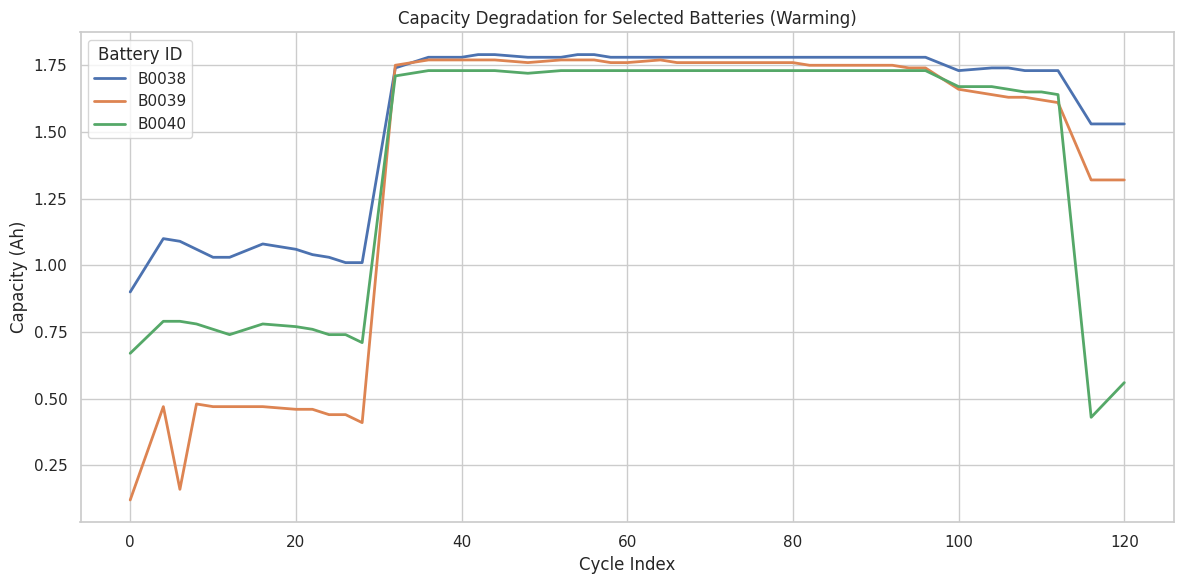

In [ ]:
metadata_clean = metadata.copy()

metadata_clean['Capacity'] = pd.to_numeric(metadata_clean['Capacity'], errors='coerce').round(2)

metadata_clean = metadata_clean.dropna(subset=['Capacity'])
cap_df = metadata_clean[(metadata_clean['type'] == 'discharge') & (metadata_clean['Capacity'].notna())]

cap_df = cap_df.sort_values(by=['battery_id', 'test_id'])
selected_batteries = ['B0038', 'B0039', 'B0040']
cap_df_filtered = cap_df[cap_df['battery_id'].isin(selected_batteries)]

plt.figure(figsize=(12,6))
sns.lineplot(data=cap_df_filtered, x='test_id', y='Capacity', hue='battery_id', linewidth=2)
plt.title('Capacity Degradation for Selected Batteries (Warming)')
plt.xlabel('Cycle Index')
plt.ylabel('Capacity (Ah)')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Battery ID')
plt.show()


Now the batteries with Step down T

**Capacity Degradation Comparison Across Batteries**

## Visualising Discharge Cycles

Lets start with cycle1

In [ ]:
row = metadata[metadata['filename'] == '00001.csv'].iloc[0]
print(row[['type', 'battery_id', 'Capacity']])


type                   discharge
battery_id                 B0047
Capacity      1.6743047446975208
Name: 0, dtype: object


In [ ]:
CYCLE_DATA_FOLDER = '/content/drive/MyDrive/BCU/THESIS/datasets/cleaned_dataset/data/'

def load_cycle_file(filename):

    file_path = os.path.join(CYCLE_DATA_FOLDER, filename)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"{filename} not found in {CYCLE_DATA_FOLDER}")

    return pd.read_csv(file_path)


In [ ]:
df = load_cycle_file('00001.csv')
df.head()


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625


### Exploring the features

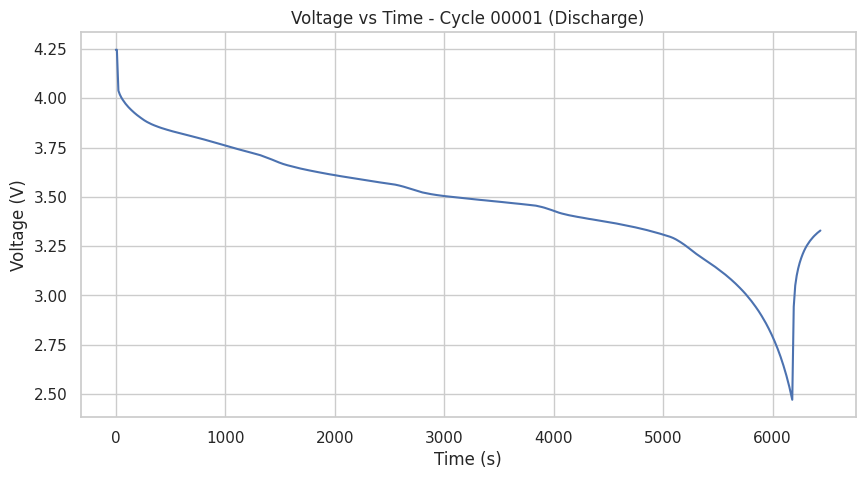

In [ ]:

plt.figure(figsize=(10,5))
plt.plot(df['Time'], df['Voltage_measured'])
plt.title('Voltage vs Time - Cycle 00001 (Discharge)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()


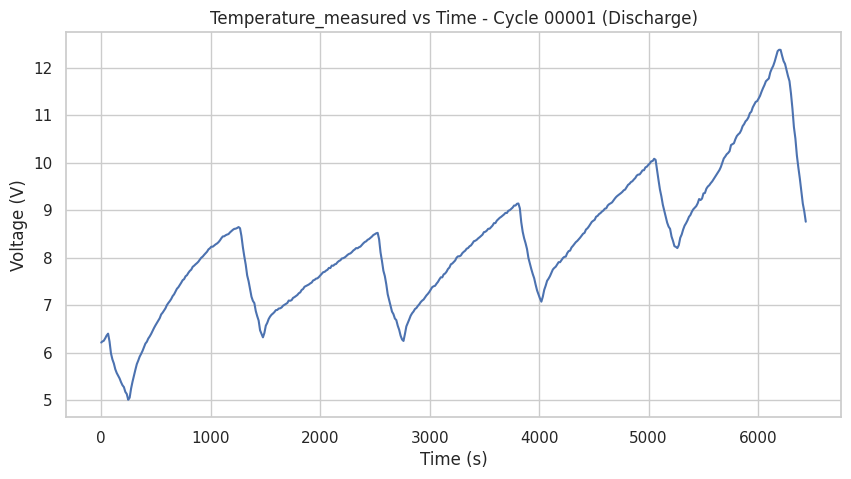

In [ ]:

plt.figure(figsize=(10,5))
plt.plot(df['Time'], df['Temperature_measured'])
plt.title('Temperature_measured vs Time - Cycle 00001 (Discharge)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()


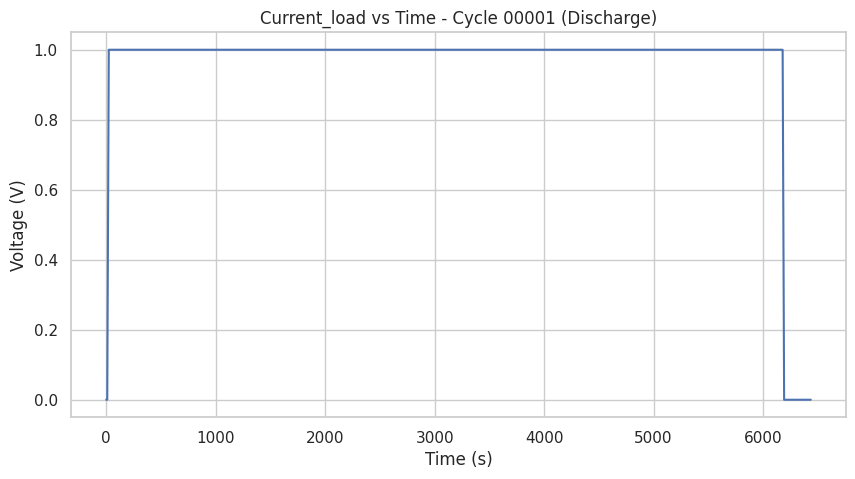

In [ ]:

plt.figure(figsize=(10,5))
plt.plot(df['Time'], df['Current_load'])
plt.title('Current_load vs Time - Cycle 00001 (Discharge)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()


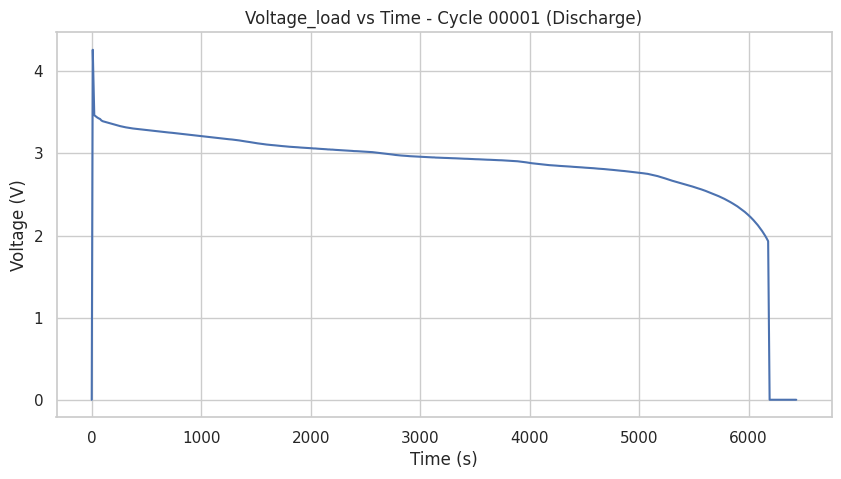

In [ ]:

plt.figure(figsize=(10,5))
plt.plot(df['Time'], df['Voltage_load'])
plt.title('Voltage_load vs Time - Cycle 00001 (Discharge)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()


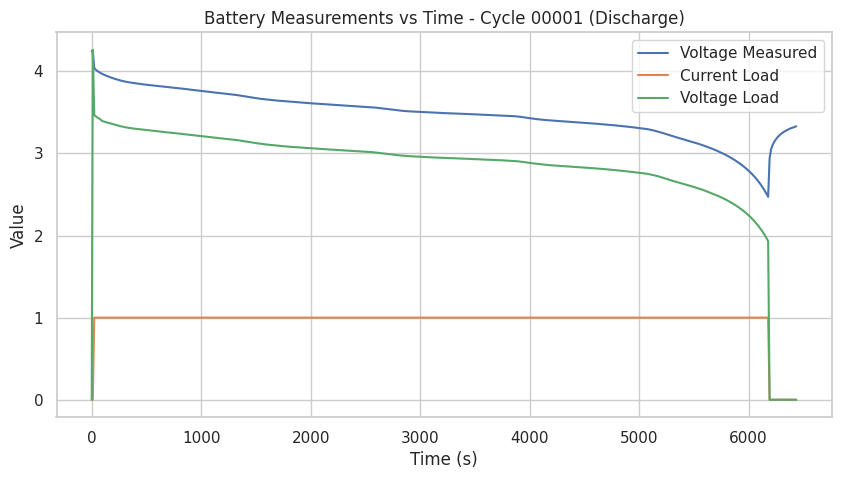

In [ ]:

plt.figure(figsize=(10,5))

# Plot each line with a label
plt.plot(df['Time'], df['Voltage_measured'], label='Voltage Measured')
plt.plot(df['Time'], df['Current_load'], label='Current Load')
plt.plot(df['Time'], df['Voltage_load'], label='Voltage Load')


plt.title('Battery Measurements vs Time - Cycle 00001 (Discharge)')
plt.xlabel('Time (s)')
plt.ylabel('Value')


plt.grid(True)

plt.legend()

plt.show()

In [ ]:
# Get only discharge entries
discharge_meta = metadata[metadata['type'] == 'discharge']

sample_files = discharge_meta.iloc[[0, 50, 100, 500, 1000]]['filename'].values
sample_files


array(['00001.csv', '00127.csv', '00257.csv', '01267.csv', '02517.csv'],
      dtype=object)

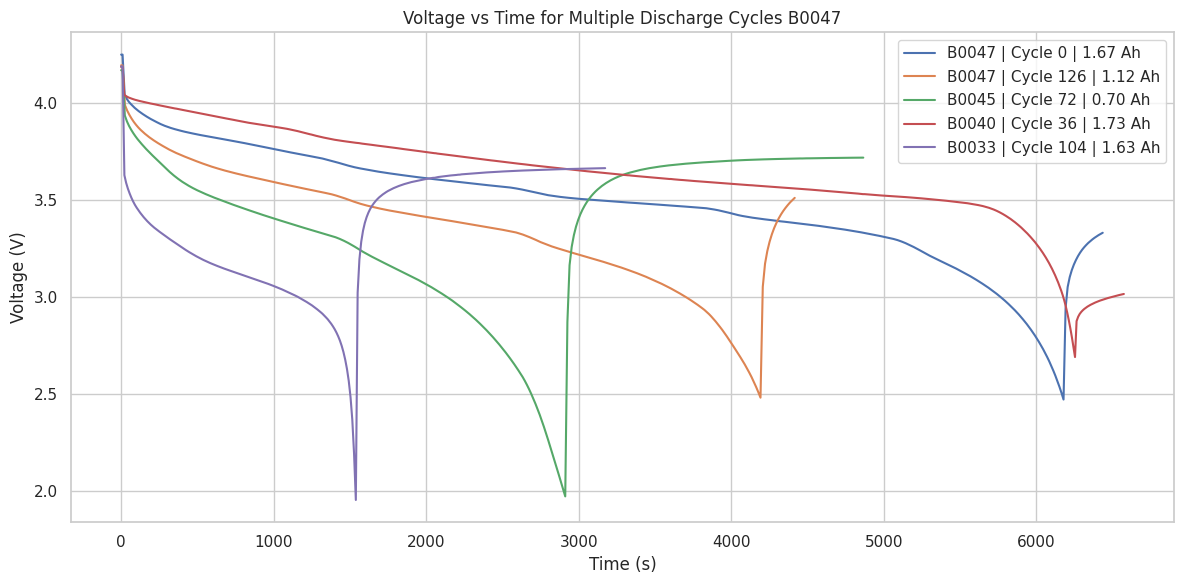

In [ ]:
sample_files = discharge_meta.iloc[[0, 50, 100, 500, 1000]]['filename'].values

plt.figure(figsize=(12, 6))

for filename in sample_files:
    df = load_cycle_file(filename)
    meta_row = metadata[metadata['filename'] == filename].iloc[0]

    battery = meta_row['battery_id']
    capacity = float(meta_row['Capacity'])
    cycle_index = meta_row['test_id']

    label = f'{battery} | Cycle {cycle_index} | {capacity:.2f} Ah'
    plt.plot(df['Time'], df['Voltage_measured'], label=label)

plt.title('Voltage vs Time for Multiple Discharge Cycles B0047')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


From this, we can conclude that the batteries have different parameter -different conditions-, perhaps this means that they have been made to simulate different situations, like high temperature, not getting charged fully, and then going to the discharge cycle reguardless... Meaning when studying the batteries, we should understand the differences, and the real life situation that is being simulated.

### 📘 Dataset Context and Discharge Profile Variability



The plotted discharge curves reflect cycles from various Li-ion battery groups, each subjected to distinct experimental conditions. According to the dataset documentation:

- **Discharge Cutoff Voltage**: Varies by battery, typically between **2.0V and 2.7V** depending on the group (e.g., 2.2V for B0040, 2.7V for B0005).
- **Load Current Levels**: Ranged from **1A to 4A** across experiments. Some used fixed loads (e.g., 2A constant), while others employed dynamic square wave profiles.
- **Ambient Temperature**: Most groups operated at **room temperature (24°C)**, while later sets (e.g., batteries #41–56) were tested at **low temperature (4°C)**, which affects discharge performance and resistance :contentReference.
- **End-of-Life (EOL) Criteria**: Defined as either **30% or 20% fade in rated capacity**, e.g., from 2.0Ah to 1.4Ah. Some batteries were stopped due to software crashes before reaching EOL.

These factors cause **observable differences in voltage drop rate, cycle duration, and capacity output** between batteries, even when plotted together. For example, a 4A square wave profile leads to sharper voltage declines than a 1A constant load.

Therefore, when comparing discharge behavior across cycles, it is crucial to account for:
- Battery ID (which implies a discharge policy and ambient temp)
- Load current intensity
- Cutoff voltage threshold
- Degradation stage (early vs late cycle)

These experimental variables are embedded in the dataset and can be retrieved via the metadata table or the associated README documents for precise modeling and interpretability.


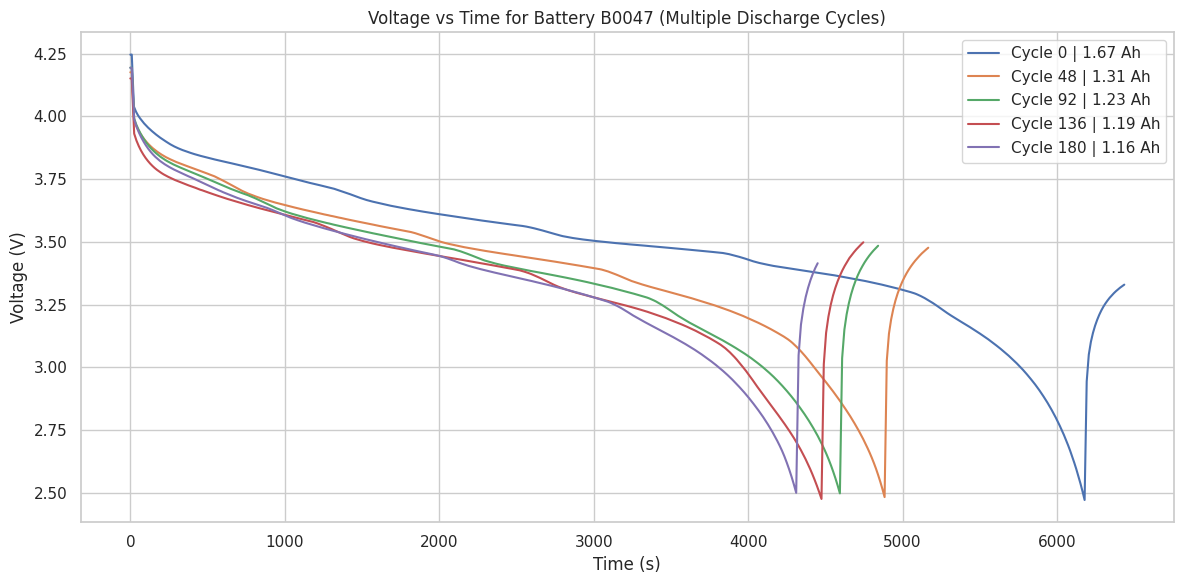

In [ ]:
# Filter for B0047 discharge cycles
b47_discharges = metadata[(metadata['battery_id'] == 'B0047') & (metadata['type'] == 'discharge')]


valid_indices = [0, 18, 36, 54, 71]
b47_sample_files = b47_discharges.iloc[valid_indices]['filename'].values


plt.figure(figsize=(12, 6))

for filename in b47_sample_files:
    df = load_cycle_file(filename)
    meta_row = metadata[metadata['filename'] == filename].iloc[0]

    cycle_id = meta_row['test_id'] if 'test_id' in meta_row else meta_row['uid']
    capacity = meta_row['Capacity']
    label = f'Cycle {cycle_id} | {float(capacity):.2f} Ah'

    plt.plot(df['Time'], df['Voltage_measured'], label=label)

plt.title('Voltage vs Time for Battery B0047 (Multiple Discharge Cycles)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Temperature Over Time (B0047)

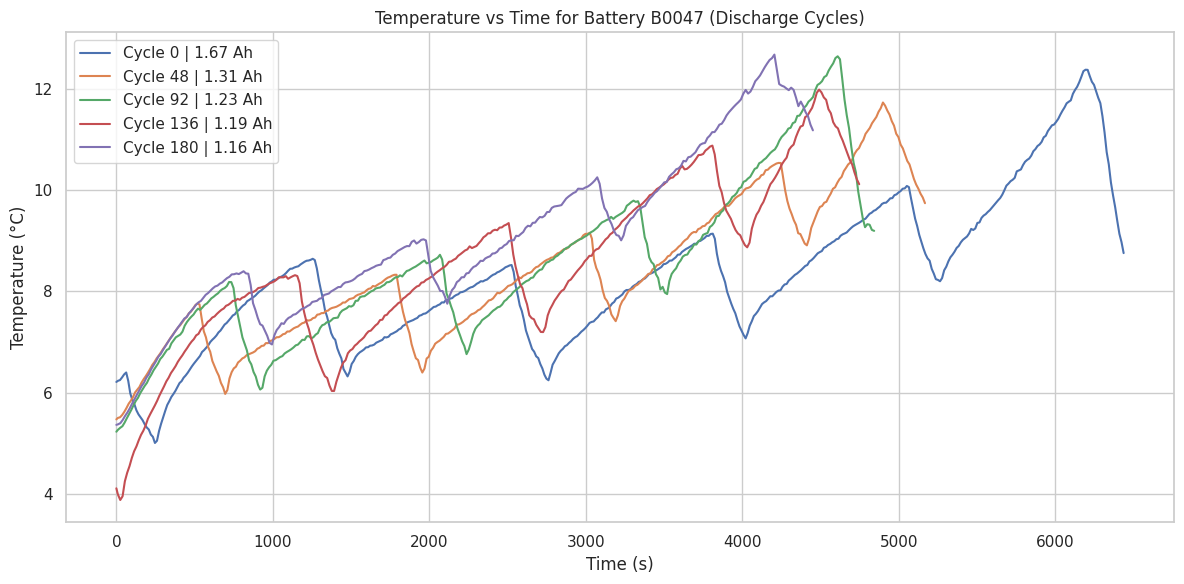

In [ ]:
plt.figure(figsize=(12, 6))

for filename in b47_sample_files:
    df = load_cycle_file(filename)
    meta_row = metadata[metadata['filename'] == filename].iloc[0]

    cycle_id = meta_row['test_id']
    capacity = meta_row['Capacity']
    label = f'Cycle {cycle_id} | {float(capacity):.2f} Ah'

    plt.plot(df['Time'], df['Temperature_measured'], label=label)

plt.title('Temperature vs Time for Battery B0047 (Discharge Cycles)')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Current Draw (Load Current) Over Time

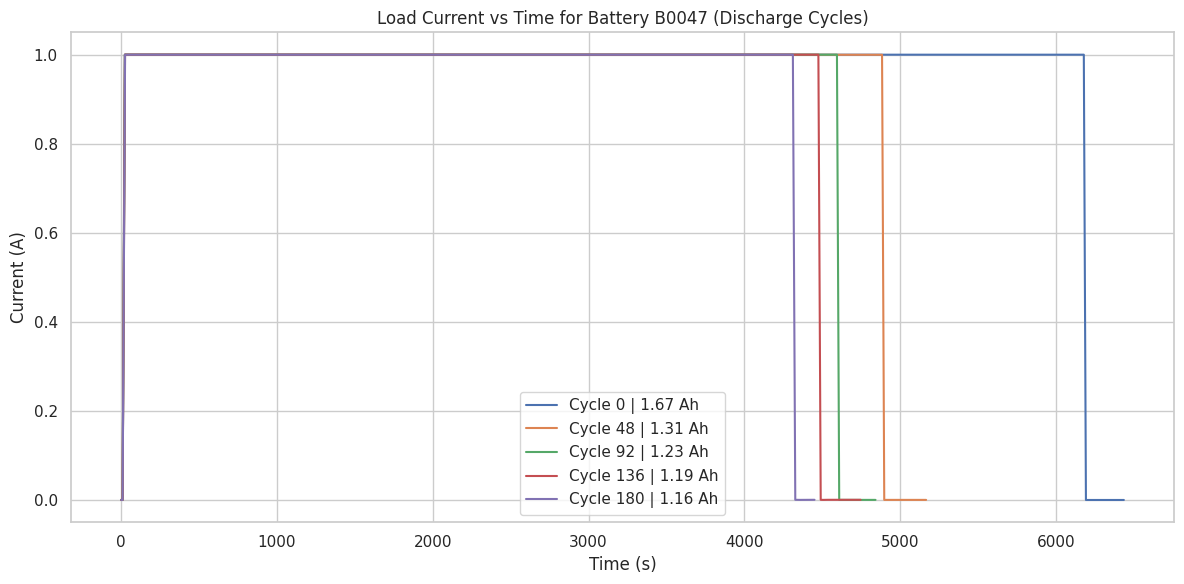

In [ ]:
plt.figure(figsize=(12, 6))

for filename in b47_sample_files:
    df = load_cycle_file(filename)
    meta_row = metadata[metadata['filename'] == filename].iloc[0]

    cycle_id = meta_row['test_id']
    capacity = meta_row['Capacity']
    label = f'Cycle {cycle_id} | {float(capacity):.2f} Ah'

    plt.plot(df['Time'], df['Current_load'], label=label)

plt.title('Load Current vs Time for Battery B0047 (Discharge Cycles)')
plt.xlabel('Time (s)')
plt.ylabel('Current (A)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Load Voltage Over Time

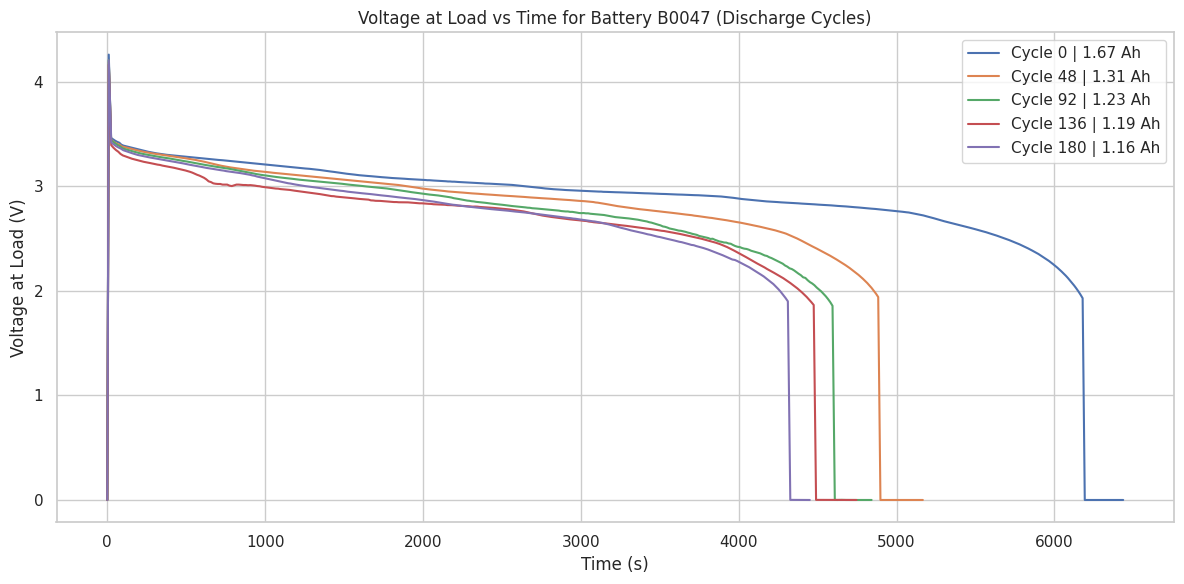

In [ ]:
plt.figure(figsize=(12, 6))

for filename in b47_sample_files:
    df = load_cycle_file(filename)
    meta_row = metadata[metadata['filename'] == filename].iloc[0]

    cycle_id = meta_row['test_id']
    capacity = meta_row['Capacity']
    label = f'Cycle {cycle_id} | {float(capacity):.2f} Ah'

    plt.plot(df['Time'], df['Voltage_load'], label=label)

plt.title('Voltage at Load vs Time for Battery B0047 (Discharge Cycles)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage at Load (V)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Temperature Clustering


In [ ]:
metadata.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [ ]:

# Defining batteries in each group
constant_batteries = [
    'B0005', 'B0006', 'B0007', 'B0047',
    'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030',
    'B0031', 'B0032', 'B0033', 'B0040', 'B0045', 'B0046',
    'B0048', 'B0050', 'B0052', 'B0053', 'B0054', 'B0055', 'B0056','B0018', 'B0034', 'B0036', 'B0041', 'B0049', 'B0051'
]
warming_batteries = ['B0038', 'B0039', 'B0040']
cooling_batteries = ['B0042', 'B0043', 'B0044']

# Defining a function to label the battery
def label_temp_group(battery_id):
    if battery_id in constant_batteries:
        return 'constant'
    elif battery_id in warming_batteries:
        return 'warming'
    elif battery_id in cooling_batteries:
        return 'cooling'
    else:
        return 'unknown'

# Applying the tag
metadata['temperature_behavior'] = metadata['battery_id'].apply(label_temp_group)

# metadata.to_csv('tagged_metadata.csv', index=False)

# Preview
print(metadata[['battery_id', 'temperature_behavior']].drop_duplicates().sort_values('battery_id'))


     battery_id temperature_behavior
5120      B0005             constant
4504      B0006             constant
5736      B0007             constant
6352      B0018             constant
3999      B0025             constant
4079      B0026             constant
3158      B0027             constant
1449      B0028             constant
1352      B0029             constant
2898      B0030             constant
4159      B0031             constant
1011      B0032             constant
2412      B0033             constant
1804      B0034             constant
3513      B0036             constant
2290      B0038              warming
1108      B0039              warming
1230      B0040             constant
2995      B0041             constant
1529      B0042              cooling
736       B0043              cooling
3238      B0044              cooling
184       B0045             constant
552       B0046             constant
0         B0047             constant
368       B0048             constant
4

In [ ]:
metadata.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,temperature_behavior
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN,constant
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333,constant
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN,constant
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734,constant
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN,constant


# Feature engineering

In [ ]:
# Feature extraction function
def extract_cycle_features(filename):
    path = os.path.join(base_data_path, filename)
    if not os.path.exists(path):
        return None

    try:
        df = pd.read_csv(path)
        if df.empty:
            return None

        cycle_type = "discharge" if 'Current_load' in df.columns else "charge"
        duration = df['Time'].max() - df['Time'].min()
        voltage = df['Voltage_measured']
        current = df['Current_measured']
        temp = df['Temperature_measured']

        voltage_gradient = (voltage.iloc[-1] - voltage.iloc[0]) / duration if duration > 0 else 0
        energy = (voltage * current).sum() * (df['Time'].iloc[1] - df['Time'].iloc[0])

        return {
            'filename': filename,
            'cycle_type': cycle_type,
            'cycle_duration': duration,
            'avg_voltage': voltage.mean(),
            'min_voltage': voltage.min(),
            'max_voltage': voltage.max(),
            'voltage_std': voltage.std(),
            'voltage_drop': voltage.max() - voltage.min(),
            'voltage_gradient': voltage_gradient,
            'avg_current': current.mean(),
            'max_current': current.max(),
            'current_std': current.std(),
            'energy_approx': energy,
            'start_voltage': voltage.iloc[0],
            'end_voltage': voltage.iloc[-1],
            'initial_temp': temp.iloc[0],
            'final_temp': temp.iloc[-1],
            'temp_rise': temp.iloc[-1] - temp.iloc[0],
            'temp_max': temp.max(),
            'temp_min': temp.min(),
            'temp_range': temp.max() - temp.min(),
        }

    except Exception as e:
        print(f"⚠️ {filename}: {e}")
        return None

# Running feature extraction
feature_list = []
for fname in metadata['filename'].unique():
    feat = extract_cycle_features(fname)
    if feat:
        feature_list.append(feat)

# Merging and saving
features_df = pd.DataFrame(feature_list)
metadata = pd.merge(metadata, features_df, on="filename", how="left")
metadata.to_csv("/content/drive/MyDrive/BCU/THESIS/datasets/engineered_metadata.csv", index=False)

print("✅ Features merged into metadata and saved.")

⚠️ 00002.csv: 'Time'
⚠️ 00004.csv: 'Time'
⚠️ 00014.csv: 'Time'
⚠️ 00016.csv: 'Time'
⚠️ 00018.csv: 'Time'
⚠️ 00020.csv: 'Time'
⚠️ 00030.csv: 'Time'
⚠️ 00032.csv: 'Time'
⚠️ 00034.csv: 'Time'
⚠️ 00036.csv: 'Time'
⚠️ 00046.csv: 'Time'
⚠️ 00048.csv: 'Time'
⚠️ 00058.csv: 'Time'
⚠️ 00060.csv: 'Time'
⚠️ 00070.csv: 'Time'
⚠️ 00072.csv: 'Time'
⚠️ 00082.csv: 'Time'
⚠️ 00084.csv: 'Time'
⚠️ 00086.csv: 'Time'
⚠️ 00088.csv: 'Time'
⚠️ 00098.csv: 'Time'
⚠️ 00100.csv: 'Time'
⚠️ 00110.csv: 'Time'
⚠️ 00112.csv: 'Time'
⚠️ 00122.csv: 'Time'
⚠️ 00124.csv: 'Time'
⚠️ 00134.csv: 'Time'
⚠️ 00136.csv: 'Time'
⚠️ 00138.csv: 'Time'
⚠️ 00140.csv: 'Time'
⚠️ 00150.csv: 'Time'
⚠️ 00152.csv: 'Time'
⚠️ 00154.csv: 'Time'
⚠️ 00156.csv: 'Time'
⚠️ 00166.csv: 'Time'
⚠️ 00168.csv: 'Time'
⚠️ 00170.csv: 'Time'
⚠️ 00172.csv: 'Time'
⚠️ 00182.csv: 'Time'
⚠️ 00184.csv: 'Time'
⚠️ 00186.csv: 'Time'
⚠️ 00188.csv: 'Time'
⚠️ 00198.csv: 'Time'
⚠️ 00200.csv: 'Time'
⚠️ 00202.csv: 'Time'
⚠️ 00204.csv: 'Time'
⚠️ 00214.csv: 'Time'
⚠️ 00216.csv:

In [ ]:
metadata.head()

# Download it
from google.colab import files
files.download('/content/drive/MyDrive/BCU/THESIS/datasets/engineered_metadata.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>